In [ ]:
# ============================================
# 1. IMPORT LIBRARY
# ============================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, QuantileTransformer
from sklearn.decomposition import PCA
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import davies_bouldin_score
from hdbscan import validity_index
from scipy.spatial.distance import pdist, squareform
import time
import warnings
warnings.filterwarnings("ignore")
import json

# Konfigurasi umum
DATA_PATH = "Data_Final_Extended.csv"
RANDOM_SEED = 42

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Loading data from: Data_Final_Extended.csv
Total rows before cleaning: 7,548
Rows after cleaning: 7,034
Numeric features detected: 28 columns
Scaling completed (Robust + Quantile).

PCA Explained Variance Ratio per Komponen:
PC1: 0.5036
PC2: 0.0995
PC3: 0.0614
PC4: 0.0596
PC5: 0.0483
Total variansi dijelaskan: 0.772
PCA output shape: (7034, 5)


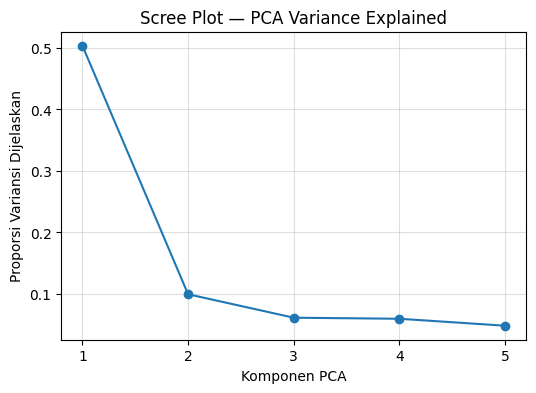

In [ ]:
# ====================================================
# 2️. LOAD & PREPROCESS DATA
# ====================================================

print(f"Loading data from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
print(f"Total rows before cleaning: {len(df):,}")

# ====================================================
# 3️. DATA CLEANING
# ====================================================

# Ganti nilai tak hingga & hilangkan baris dengan NaN
df = df.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Rows after cleaning: {len(df):,}")

# Ambil hanya fitur numerik
X = df.select_dtypes(include=[np.number])
print(f"Numeric features detected: {X.shape[1]} columns")

# ====================================================
# 4️. SCALING — Kombinasi Robust + QuantileTransformer
# ====================================================

scaler_type = "robust+quantile"

if scaler_type == "robust+quantile":
    X_scaled = RobustScaler().fit_transform(X)
    X_scaled = QuantileTransformer(
        output_distribution="normal",
        random_state=RANDOM_SEED
    ).fit_transform(X_scaled)

print("Scaling completed (Robust + Quantile).")

# ====================================================
# 5️. PCA — Reduksi Dimensi Awal
# ====================================================

n_components = 5
pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA Explained Variance Ratio per Komponen:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f}")
print(f"Total variansi dijelaskan: {np.sum(pca.explained_variance_ratio_):.3f}")
print(f"PCA output shape: {X_pca.shape}")

# ====================================================
# 6️. VISUALISASI — PCA 2D Projection
# ====================================================

plt.figure(figsize=(6, 4))
plt.plot(
    range(1, n_components + 1),
    pca.explained_variance_ratio_,
    marker="o",
    linestyle="-",
    color="tab:blue"
)
plt.title("Scree Plot — PCA Variance Explained", fontsize=12)
plt.xlabel("Komponen PCA")
plt.ylabel("Proporsi Variansi Dijelaskan")
plt.xticks(range(1, n_components + 1))
plt.grid(alpha=0.4)
plt.show()

📊 Distribusi Pemain per Cluster:
cluster
-1     454
 0     125
 1     500
 2    1073
 3    4044
 4     110
 5     219
 6     127
 7      77
 8     305
Name: count, dtype: int64

Jumlah Cluster: 9
Jumlah Outlier: 454 (6.45%)
Dominasi Cluster Terbesar: 0.575


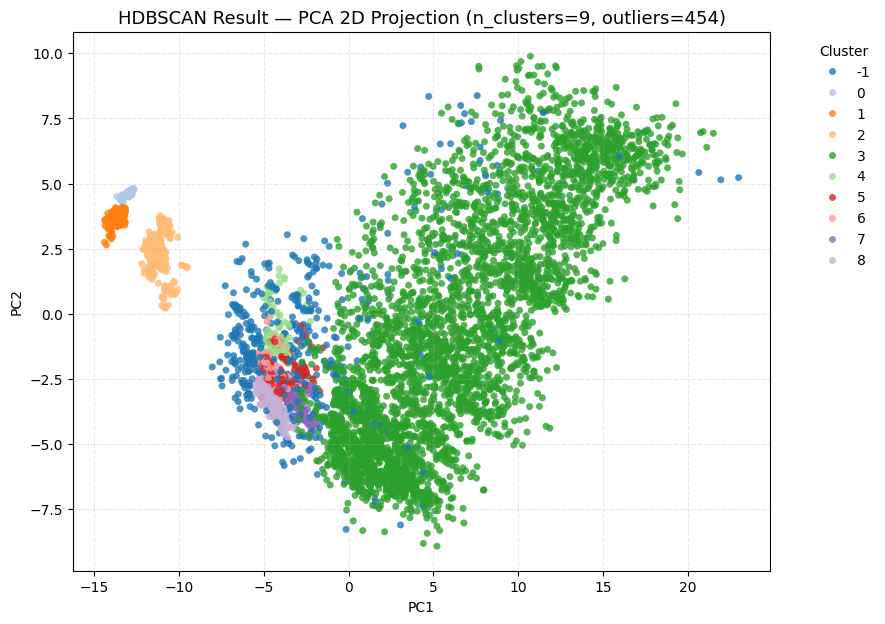

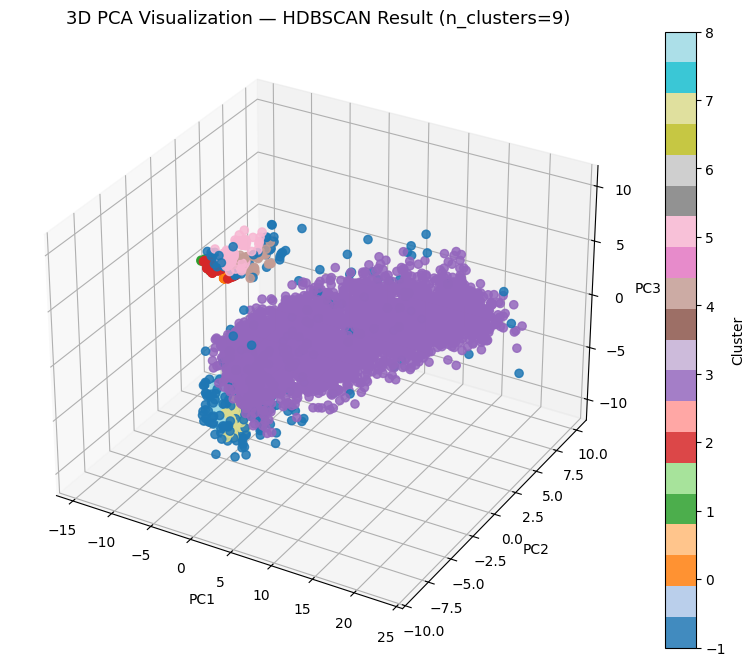

In [ ]:
# ====================================================
# 7. HDBSCAN — Clustering dengan Parameter Terbaik
# ====================================================

# Parameter terbaik hasil random search
mcs = 60
ms = 11
eps = 0.03
metric = "manhattan"
method = "eom"

# Inisialisasi model HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=mcs,
    min_samples=ms,
    cluster_selection_epsilon=eps,
    metric=metric,
    cluster_selection_method=method,
    core_dist_n_jobs=-1,
    allow_single_cluster=False
)

# Fit ke data hasil PCA
labels = clusterer.fit_predict(X_pca)

# ====================================================
# 8. Simpan hasil clustering ke DataFrame
# ====================================================
df_cluster = df.copy()
df_cluster["PC1"] = X_pca[:, 0]
df_cluster["PC2"] = X_pca[:, 1]
df_cluster["PC3"] = X_pca[:, 2]
df_cluster["cluster"] = labels

# ====================================================
# 9. Statistik Hasil Clustering
# ====================================================
cluster_counts = df_cluster["cluster"].value_counts().sort_index()
n_clusters = (cluster_counts.index != -1).sum()
outlier_count = cluster_counts.get(-1, 0)
dominance = cluster_counts[cluster_counts.index != -1].max() / len(labels)
outlier_pct = (outlier_count / len(labels)) * 100

print("📊 Distribusi Pemain per Cluster:")
print(cluster_counts)
print(f"\nJumlah Cluster: {n_clusters}")
print(f"Jumlah Outlier: {outlier_count} ({outlier_pct:.2f}%)")
print(f"Dominasi Cluster Terbesar: {dominance:.3f}")

# ====================================================
# 10. Visualisasi Hasil Clustering (2D)
# ====================================================
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df_cluster, x="PC1", y="PC2",
    hue="cluster", palette="tab20",
    s=25, alpha=0.8, edgecolor="none"
)
plt.title(f"HDBSCAN Result — PCA 2D Projection (n_clusters={n_clusters}, outliers={outlier_count})", fontsize=13)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Cluster", frameon=False)
plt.grid(alpha=0.3, linestyle="--")
plt.show()

# ====================================================
# 11. Visualisasi Hasil Clustering (3D)
# ====================================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df_cluster["PC1"], df_cluster["PC2"], df_cluster["PC3"],
    c=df_cluster["cluster"], cmap="tab20",
    s=35, alpha=0.85
)

ax.set_title(f"3D PCA Visualization — HDBSCAN Result (n_clusters={n_clusters})", fontsize=13)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.colorbar(scatter, ax=ax, label="Cluster")
plt.show()

In [ ]:
# ============================================
# 12. EVALUASI CLUSTERING HDBSCAN (DBI & DBCV)
# ============================================
df_cluster_full = df.copy()
df_cluster_full["PC1"] = X_pca[:, 0]
df_cluster_full["PC2"] = X_pca[:, 1]
df_cluster_full["PC3"] = X_pca[:, 2]
df_cluster_full["cluster"] = labels

# ===============================
# 1️3. Siapkan data hasil clustering
# ===============================
df_cluster = pd.DataFrame(X_pca[:, :3], columns=["PC1", "PC2", "PC3"])
df_cluster["cluster"] = labels

valid_mask = df_cluster["cluster"] != -1  # abaikan outlier
X_valid = df_cluster.loc[valid_mask, ["PC1", "PC2", "PC3"]].values
labels_valid = df_cluster.loc[valid_mask, "cluster"].values

# ===============================
# 14. Hitung Davies-Bouldin Index (DBI)
# ===============================
if len(np.unique(labels_valid)) > 1:
    dbi_score = davies_bouldin_score(X_valid, labels_valid)
else:
    dbi_score = np.nan

# ===============================
# 15. Hitung DBCV Manual (Manhattan)
# ===============================
ms = 11  # min_samples dari HDBSCAN
random_state = 42

X_proc = X_valid
labels_proc = labels_valid
n = X_proc.shape[0]
unique_labels = np.unique(labels_proc)

print(f"\n🔍 Mulai perhitungan DBCV — n samples: {n}, clusters: {len(unique_labels)}")

# 1) Pairwise Manhattan distances
t0 = time.time()
D = squareform(pdist(X_proc, metric="cityblock"))
print(f"   Distance matrix: {D.shape}, selesai dalam {time.time()-t0:.1f}s")

# 2) Core distances (k-th nearest neighbor)
k = max(1, ms)
core_dists = np.partition(D, kth=k, axis=1)[:, k]
core_dists = np.maximum(core_dists, 1e-12)

# 3) Mutual reachability matrix
core_i = core_dists.reshape(-1, 1)
core_j = core_dists.reshape(1, -1)
MR = np.maximum(np.maximum(core_i, core_j), D)

# 4) Cohesion & Separation per cluster
cluster_vals = {}
total_weight, weighted_sum = 0.0, 0.0

for lab in np.unique(labels_proc):
    idx = np.where(labels_proc == lab)[0]
    size = len(idx)
    if size < 2:
        continue

    # Cohesion (dalam cluster)
    MR_within = MR[np.ix_(idx, idx)]
    tril_count = size * (size - 1) // 2
    sum_within = (np.sum(MR_within) - np.sum(np.diag(MR_within))) / 2.0
    cohesion = sum_within / tril_count if tril_count > 0 else np.nan

    # Separation (antar cluster)
    other_labels = [l for l in np.unique(labels_proc) if l != lab]
    sep_vals = []
    for olab in other_labels:
        oidx = np.where(labels_proc == olab)[0]
        if len(oidx) == 0:
            continue
        MR_between = MR[np.ix_(idx, oidx)]
        avg_between = np.mean(MR_between)
        sep_vals.append(avg_between)
    separation = np.min(sep_vals) if len(sep_vals) else cohesion * 10

    # Validity score
    denom = max(separation, cohesion)
    validity = (separation - cohesion) / denom if denom > 0 else 0.0

    cluster_vals[lab] = {
        "size": size,
        "cohesion": float(cohesion),
        "separation": float(separation),
        "validity": float(validity)
    }

    total_weight += size
    weighted_sum += size * validity

dbcv_score = weighted_sum / total_weight if total_weight > 0 else np.nan

print(f"   ✅ DBCV (Manhattan) berhasil dihitung: {dbcv_score:.4f}")

# ===============================
# 16. Ringkasan distribusi cluster
# ===============================
cluster_counts = df_cluster["cluster"].value_counts().sort_index()
outlier_pct = round((df_cluster["cluster"] == -1).mean() * 100, 2)

# ===============================
# 17. Interpretasi otomatis
# ===============================
# Interpretasi DBI
if np.isnan(dbi_score):
    dbi_text = "⚠️ Tidak dapat dihitung — kurang dari 2 cluster valid."
elif dbi_score < 0.7:
    dbi_text = "🟢 Sangat baik — cluster sangat terpisah dan kompak."
elif dbi_score < 1.2:
    dbi_text = "🟡 Cukup baik — ada sedikit tumpang tindih antar cluster."
else:
    dbi_text = "🔴 Kurang baik — beberapa cluster masih saling berdekatan."

# Interpretasi DBCV (Manhattan)
if np.isnan(dbcv_score):
    dbcv_text = "⚠️ Tidak dapat dihitung — nilai DBCV tidak valid."
elif dbcv_score > 0.6:
    dbcv_text = "🟢 Sangat baik — struktur kepadatan antar cluster jelas."
elif dbcv_score > 0.3:
    dbcv_text = "🟡 Cukup stabil — variasi metrik kecil."
elif dbcv_score > 0:
    dbcv_text = "🟡 Moderat — cluster masih dapat dibedakan namun kurang optimal."
elif dbcv_score > -0.3:
    dbcv_text = "🔴 Kurang baik — struktur kepadatan lemah, cluster sulit dibedakan."
else:
    dbcv_text = "🔴 Buruk — cluster sangat overlap, struktur tidak jelas."

# Kombinasi analisis
if not np.isnan(dbi_score) and not np.isnan(dbcv_score):
    if dbi_score > 1.2 and dbcv_score < 0:
        combo_text = "⚠️ Kombinasi metrik menunjukkan cluster terlalu padat di satu area dan tidak seimbang. Perlu tuning parameter seperti `min_cluster_size` atau coba metrik jarak lain."
    elif dbi_score < 1 and dbcv_score > 0.4:
        combo_text = "✅ Hasil seimbang — cluster cukup stabil dan terpisah dengan baik."
    elif dbi_score < 1.3 and dbcv_score > 0.2:
        combo_text = "🟡 Hasil cukup baik — clustering menunjukkan pola yang dapat diterima."
    else:
        combo_text = "ℹ️ Hasil masih bisa ditingkatkan — kemungkinan masih ada noise atau distribusi fitur belum optimal."
else:
    combo_text = "⚠️ Evaluasi tidak lengkap — metrik tidak valid untuk semua cluster."

# ===============================
# 18. Tabel ringkasan evaluasi
# ===============================
summary_df = pd.DataFrame({
    "Metrik": [
        "Davies–Bouldin Index (DBI)",
        "Density-Based Cluster Validity (DBCV – Manhattan)"
    ],
    "Nilai": [
        f"{dbi_score:.4f}" if not np.isnan(dbi_score) else "NaN",
        f"{dbcv_score:.4f}" if not np.isnan(dbcv_score) else "NaN"
    ],
    "Interpretasi": [dbi_text, dbcv_text]
})

print("\n" + "="*80)
print("📊 RINGKASAN EVALUASI CLUSTERING")
print("="*80)
print(summary_df.to_string(index=False))

print("\n📈 Distribusi pemain per cluster:")
print(cluster_counts)

print(f"\nPersentase outlier: {outlier_pct}%")

print("\nAnalisis Umum:")
print(combo_text)
print("="*80)


🔍 Mulai perhitungan DBCV — n samples: 6580, clusters: 9
   Distance matrix: (6580, 6580), selesai dalam 1.1s
   ✅ DBCV (Manhattan) berhasil dihitung: 0.4458

📊 RINGKASAN EVALUASI CLUSTERING
                                           Metrik  Nilai                                             Interpretasi
                       Davies–Bouldin Index (DBI) 0.7711 🟡 Cukup baik — ada sedikit tumpang tindih antar cluster.
Density-Based Cluster Validity (DBCV – Manhattan) 0.4458                   🟡 Cukup stabil — variasi metrik kecil.

📈 Distribusi pemain per cluster:
cluster
-1     454
 0     125
 1     500
 2    1073
 3    4044
 4     110
 5     219
 6     127
 7      77
 8     305
Name: count, dtype: int64

Persentase outlier: 6.45%

Analisis Umum:
✅ Hasil seimbang — cluster cukup stabil dan terpisah dengan baik.


In [ ]:
# ============================================================
# 19. SIMPAN HASIL EVALUASI
# ============================================================
evaluation_result = {
    "dbi_score": float(dbi_score),
    "dbcv_score": float(dbcv_score),
    "n_clusters": int(n_clusters),
    "outliers": int(outlier_count),
    "outlier_percentage": float(outlier_pct),
    "interpretation": {
        "dbi": dbi_text,
        "dbcv": dbcv_text,
        "overall": combo_text
    }
}

with open("evaluation_result.json", "w", encoding="utf-8") as f:
    json.dump(evaluation_result, f, ensure_ascii=False, indent=2)
print("\nevaluation_result.json berhasil dibuat")

# ============================================================
# 20. EKSPOR BIODATA PEMAIN
# ============================================================

print("\n" + "="*80)
print("EKSPOR BIODATA PEMAIN")
print("="*80)

# Daftar kolom biodata utama + 10 kolom data performa per musim
biodata_cols = [
    "player_name", "age", "last_year_played", "sub_position",
    "country_of_citizenship", "club_name", "league_name",
    "total_minutes", "total_matches", "starter_percentage",
    "substitute_percentage", "total_goals", "total_assists", "total_GA",
    "goals_season1", "goals_season2", "goals_season3", "goals_season4", "goals_season5",
    "assists_season1", "assists_season2", "assists_season3", "assists_season4", "assists_season5"
]

# Cek kolom mana yang tersedia di DataFrame
available_cols = [col for col in biodata_cols if col in df.columns]
missing_cols = [col for col in biodata_cols if col not in df.columns]

# Tampilkan peringatan jika ada kolom yang hilang
if missing_cols:
    print(f"Kolom tidak ditemukan dan akan dilewati: {missing_cols}")

# Buat salinan DataFrame khusus untuk biodata
df_biodata_export = df[available_cols].copy()

# Pastikan nama pemain bersih (tidak ada spasi berlebih atau nilai NaN)
if "player_name" in df_biodata_export.columns:
    df_biodata_export["player_name"] = (
        df_biodata_export["player_name"]
        .astype(str)
        .str.strip()
        .replace("nan", None)
    )

# Tampilkan ringkasan singkat data yang akan diekspor
print("\nRingkasan Data Biodata:")
print(f"- Jumlah pemain       : {len(df_biodata_export):,}")
print(f"- Kolom diekspor      : {available_cols}")
print(f"- Nilai kosong (NaN)  : {df_biodata_export.isna().sum().sum():,} total")

# Simpan file JSON
biodata_path = "player_biodata.json"
df_biodata_export.to_json(biodata_path, orient="records", force_ascii=False, indent=2)

print(f"File JSON berhasil dibuat: {biodata_path}")
# ============================================================
# 21. EKSPOR HASIL CLUSTERING
# ============================================================
print("\n" + "="*80)
print("EKSPOR HASIL CLUSTERING")
print("="*80)

# Buat DataFrame hasil clustering
df_pca = df.copy()
df_pca["PC1"] = X_pca[:, 0]
df_pca["PC2"] = X_pca[:, 1]
df_pca["PC3"] = X_pca[:, 2]
df_pca["cluster"] = labels

cluster_export_cols = ["player_name", "PC1", "PC2", "PC3", "cluster"]

# Tambahkan kolom statistik jika ada
stats_cols = ["G90_shrink", "A90_shrink", "GA90_shrink", "total_minutes", "total_matches",
              "starter_percentage", "substitute_percentage", "total_goals", "total_assists"]
for col in stats_cols:
    if col in df_pca.columns:
        cluster_export_cols.append(col)

print(f"Kolom yang akan diekspor: {cluster_export_cols}")

cluster_export_cols = [c for c in cluster_export_cols if c in df_pca.columns]

df_cluster_export = df_pca[cluster_export_cols].copy()

# Rename kolom untuk readability
rename_map = {
    "G90_shrink": "goals_per_90",
    "A90_shrink": "assists_per_90",
    "GA90_shrink": "goal_contributions_per_90"
}
for old, new in rename_map.items():
    if old in df_cluster_export.columns:
        df_cluster_export = df_cluster_export.rename(columns={old: new})

print(f"Kolom setelah rename: {df_cluster_export.columns.tolist()}")

df_cluster_export["cluster"] = df_cluster_export["cluster"].astype(int)
df_cluster_export = df_cluster_export.where(pd.notnull(df_cluster_export), None)

cluster_path = "cluster_results.json"
df_cluster_export.to_json(cluster_path, orient="records", force_ascii=False, indent=2)
print(f"'{cluster_path}' berhasil dibuat ({len(df_cluster_export):,} pemain)")

# ============================================================
# 22. EKSPOR RINGKASAN CLUSTER
# ============================================================
print("\n" + "="*80)
print("EKSPOR RINGKASAN CLUSTER")
print("="*80)

stats_cols = [c for c in ["goals_per_90", "assists_per_90", "goal_contributions_per_90", "total_minutes"] if c in df_cluster_export.columns]

cluster_stats = df_cluster_export.groupby("cluster")[stats_cols].agg(["mean", "count"])
cluster_stats.columns = ['_'.join(col).strip() for col in cluster_stats.columns.values]
cluster_stats = cluster_stats.reset_index()

all_players = df_cluster_export.groupby("cluster")["player_name"].apply(lambda x: x.dropna().astype(str).tolist()).reset_index()

summary = []
for _, row in cluster_stats.iterrows():
    cluster_id = int(row["cluster"])
    players_list = all_players.loc[all_players["cluster"] == cluster_id, "player_name"].values[0]

    # Build statistik dengan nama field yang sesuai untuk React
    avg_stats = {}

    # Mapping ke nama yang diharapkan di React
    field_mapping = {
        "goals_per_90": "G90",
        "assists_per_90": "A90",
        "goal_contributions_per_90": "GA90",
        "total_minutes": "minutes"
    }

    for col in stats_cols:
        mean_val = row.get(f"{col}_mean", np.nan)
        if not pd.isna(mean_val):
            # Gunakan nama field React
            react_field_name = field_mapping.get(col, col)
            avg_stats[react_field_name] = round(float(mean_val), 3)

    summary.append({
        "cluster": cluster_id,
        "label": f"Cluster {cluster_id}" if cluster_id != -1 else "Outliers",
        "description": "",  # Bisa diisi manual nanti
        "n_players": len(players_list),
        "avg_stats": avg_stats,
        "players": players_list,
        "full_analysis": ""  # Untuk popup detail
    })

summary = sorted(summary, key=lambda x: x["cluster"])

# Debug: tampilkan contoh statistik dari cluster pertama
if summary:
    print(f"\nContoh avg_stats dari cluster pertama:")
    print(f"   Cluster ID: {summary[0]['cluster']}")
    print(f"   Statistik: {summary[0]['avg_stats']}")

summary_path = "cluster_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f"\n'{summary_path}' berhasil dibuat")
print(f"\nRingkasan per cluster:")
for item in summary:
    stats_preview = ", ".join([f"{k}={v}" for k, v in list(item['avg_stats'].items())[:3]])
    print(f"   {item['label']:>12}: {item['n_players']:>4} pemain | Stats: {stats_preview}")

print("\n" + "="*80)
print("EKSPOR SELESAI - Siap untuk visualisasi web!")
print("="*80)
print(f"\nFile yang dibuat:")
print(f"   1. evaluation_result.json - Hasil evaluasi clustering")
print(f"   2. {biodata_path} - Biodata lengkap semua pemain")
print(f"   3. {cluster_path} - Hasil clustering dengan koordinat PCA")
print(f"   4. {summary_path} - Ringkasan cluster dengan SEMUA nama pemain")
print("="*80)


evaluation_result.json berhasil dibuat

EKSPOR BIODATA PEMAIN

Ringkasan Data Biodata:
- Jumlah pemain       : 7,034
- Kolom diekspor      : ['player_name', 'age', 'last_year_played', 'sub_position', 'country_of_citizenship', 'club_name', 'league_name', 'total_minutes', 'total_matches', 'starter_percentage', 'substitute_percentage', 'total_goals', 'total_assists', 'total_GA', 'goals_season1', 'goals_season2', 'goals_season3', 'goals_season4', 'goals_season5', 'assists_season1', 'assists_season2', 'assists_season3', 'assists_season4', 'assists_season5']
- Nilai kosong (NaN)  : 0 total
File JSON berhasil dibuat: player_biodata.json

EKSPOR HASIL CLUSTERING
Kolom yang akan diekspor: ['player_name', 'PC1', 'PC2', 'PC3', 'cluster', 'G90_shrink', 'A90_shrink', 'GA90_shrink', 'total_minutes', 'total_matches', 'starter_percentage', 'substitute_percentage', 'total_goals', 'total_assists']
Kolom setelah rename: ['player_name', 'PC1', 'PC2', 'PC3', 'cluster', 'goals_per_90', 'assists_per_90', 'g

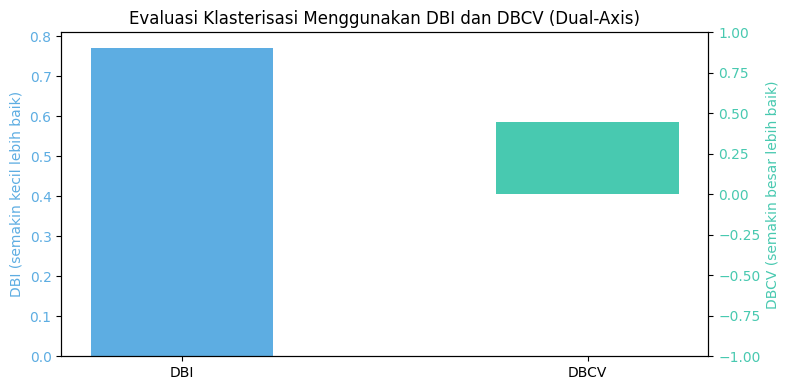

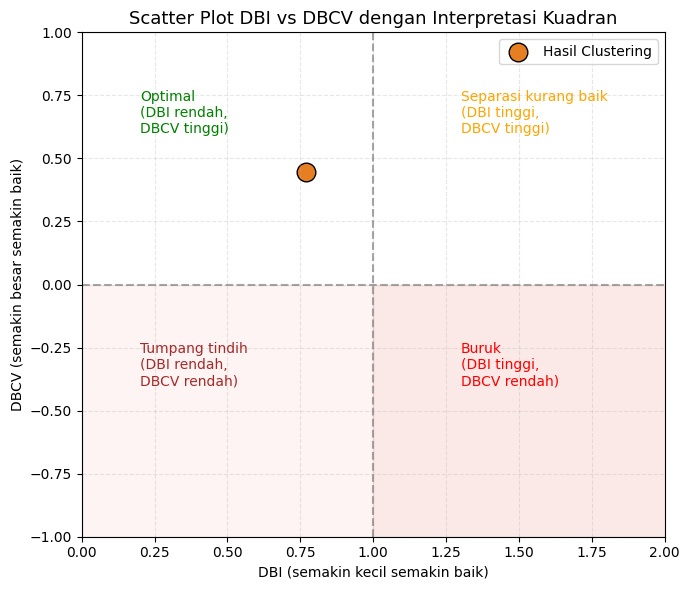

In [ ]:
dbi_value = dbi_score
dbcv_value = dbcv_score

fig, ax1 = plt.subplots(figsize=(8,4))

# --- Bar DBI (sumbu kiri) ---
color1 = "#5DADE2"
ax1.bar(["DBI"], [dbi_value], color=color1, width=0.45)
ax1.set_ylabel("DBI (semakin kecil lebih baik)", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# --- Bar DBCV (sumbu kanan) ---
ax2 = ax1.twinx()
color2 = "#48C9B0"
ax2.bar(["DBCV"], [dbcv_value], color=color2, width=0.45)
ax2.set_ylabel("DBCV (semakin besar lebih baik)", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(-1, 1)

# --- Judul ---
plt.title("Evaluasi Klasterisasi Menggunakan DBI dan DBCV (Dual-Axis)")

plt.tight_layout()
plt.show()

# Nilai metrik
x_val = dbi_value
y_val = dbcv_value

# Threshold (umum digunakan dalam literatur)
dbi_threshold = 1.0
dbcv_threshold = 0.0

plt.figure(figsize=(7,6))

# --- Scatter point utama (hasil clustering) ---
plt.scatter(x_val, y_val, s=180, c="#E67E22", edgecolor="black", label="Hasil Clustering")

# --- Garis batas kuadran ---
plt.axvline(dbi_threshold, color="gray", linestyle="--", alpha=0.7)
plt.axhline(dbcv_threshold, color="gray", linestyle="--", alpha=0.7)

# --- Shading tiap kuadran (opsional tapi sangat bagus untuk skripsi) ---
plt.axvspan(0, dbi_threshold, ymin=dbcv_threshold + 1, ymax=1, color="#ABEBC6", alpha=0.3)  # Q1
plt.axvspan(dbi_threshold, 3, ymin=dbcv_threshold + 1, ymax=1, color="#F9E79F", alpha=0.3)  # Q2
plt.axvspan(0, dbi_threshold, ymin=0, ymax=0.5, color="#FADBD8", alpha=0.3)                 # Q3
plt.axvspan(dbi_threshold, 3, ymin=0, ymax=0.5, color="#F5B7B1", alpha=0.3)                 # Q4

# --- Label interpretasi kuadran ---
plt.text(0.2, 0.6, "Optimal\n(DBI rendah,\nDBCV tinggi)", fontsize=10, color="green")

plt.text(1.3, 0.6, "Separasi kurang baik\n(DBI tinggi,\nDBCV tinggi)", fontsize=10, color="orange")

plt.text(0.2, -0.4, "Tumpang tindih\n(DBI rendah,\nDBCV rendah)", fontsize=10, color="brown")

plt.text(1.3, -0.4, "Buruk\n(DBI tinggi,\nDBCV rendah)", fontsize=10, color="red")

# --- Label & layout ---
plt.title("Scatter Plot DBI vs DBCV dengan Interpretasi Kuadran", fontsize=13)
plt.xlabel("DBI (semakin kecil semakin baik)")
plt.ylabel("DBCV (semakin besar semakin baik)")
plt.grid(alpha=0.3, linestyle="--")
plt.xlim(0, max(2, x_val + 0.5))
plt.ylim(-1, 1)

plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

ANALISIS KARAKTERISTIK KLASTER

[1] KARAKTERISTIK MASING-MASING CLUSTER

Jumlah Pemain per Cluster:
  Cluster -1: 454 pemain (6.5%)
  Cluster 0: 125 pemain (1.8%)
  Cluster 1: 500 pemain (7.1%)
  Cluster 2: 1073 pemain (15.3%)
  Cluster 3: 4044 pemain (57.5%)
  Cluster 4: 110 pemain (1.6%)
  Cluster 5: 219 pemain (3.1%)
  Cluster 6: 127 pemain (1.8%)
  Cluster 7: 77 pemain (1.1%)
  Cluster 8: 305 pemain (4.3%)

----------------------------------------------------------------------
Statistik Deskriptif per Cluster (Mean ± Std):
----------------------------------------------------------------------

Cluster -1:
  G90                :    0.68 ±  2.67  (Median:   0.32)
  A90                :    0.28 ±  1.29  (Median:   0.00)
  GA90               :    0.96 ±  2.90  (Median:   0.43)
  total_minutes      : 1241.51 ± 1937.31  (Median: 622.00)
  total_matches      :   28.84 ± 31.94  (Median:  16.00)
  age                :   23.06 ±  4.33  (Median:  22.00)

Cluster 0:
  G90                :    0

,G90,A90,GA90,total_minutes,total_matches,age
cluster,,,,,,
-1,0.68,0.28,0.96,1241.51,28.84,23.06
0,0.00,0.00,0.00,111.70,6.30,19.98
1,0.00,0.00,0.00,47.55,7.29,20.77
2,0.00,0.00,0.00,204.24,16.17,22.61
3,0.29,0.17,0.46,4076.47,70.51,25.68
4,0.00,0.26,0.26,695.00,29.96,23.72
5,0.00,0.44,0.44,546.29,22.82,23.96
6,0.31,0.00,0.31,630.93,29.27,24.02
7,0.41,0.00,0.41,1066.65,31.92,25.09



[2] BOXPLOT DISTRIBUSI FITUR PER CLUSTER


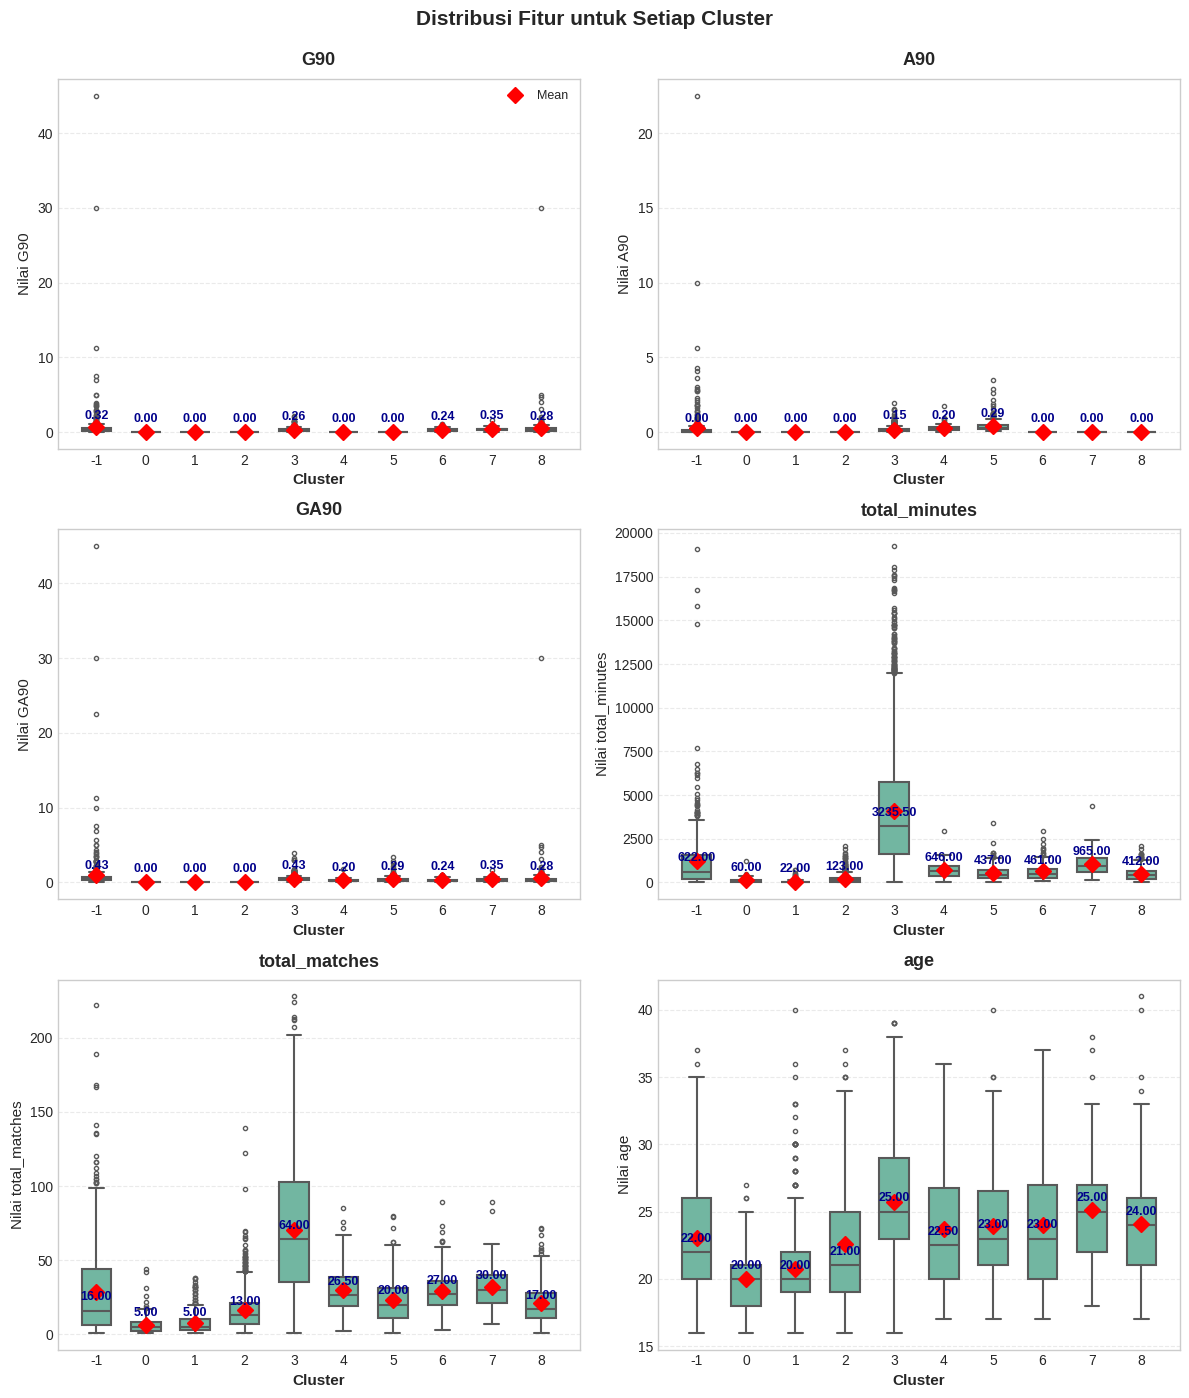


[3] INTERPRETASI BERDASARKAN BUKTI VISUAL

Analisis Karakteristik (Berdasarkan Data):

CLUSTER -1
Jumlah: 454 pemain

Karakteristik Kunci:
  • G90                :   0.68 - sangat tinggi   (179% di atas rata-rata)
  • A90                :   0.28 - sangat tinggi   (106% di atas rata-rata)
  • GA90               :   0.96 - sangat tinggi   (153% di atas rata-rata)
  • total_minutes      : 1241.51 - sangat rendah   (51% di bawah rata-rata)
  • total_matches      :  28.84 - sangat rendah   (40% di bawah rata-rata)
  • age                :  23.06 - sedang          (sekitar rata-rata)

Contoh Pemain Representatif (5 teratas berdasarkan GA90):
  Jesper Uneken             (Eindhovense Voetbalvereniging Philips Sport Vereniging) | G90=45.00, A90=0.00, GA90=45.00
  André Ferreira            (CS Marítimo         ) | G90=30.00, A90=0.00, GA90=30.00
  Tommaso De Nipoti         (Atalanta Bergamasca Calcio S.p.a.) | G90=0.00, A90=22.50, GA90=22.50
  Jack Lahne                (Amiens SC           ) | 

In [ ]:
# ========================================
# PERSIAPAN DATA
# ========================================
df_cluster = df.copy()
df_cluster["PC1"] = X_pca[:, 0]
df_cluster["PC2"] = X_pca[:, 1]
df_cluster["PC3"] = X_pca[:, 2]
df_cluster["cluster"] = labels

print("="*70)
print("ANALISIS KARAKTERISTIK KLASTER")
print("="*70)

# ========================================
# 1. STATISTIK KARAKTERISTIK CLUSTER
# ========================================
print("\n[1] KARAKTERISTIK MASING-MASING CLUSTER")
print("="*70)

features_main = ["G90", "A90", "GA90", "total_minutes", "total_matches", "age"]

# Jumlah anggota per cluster
print("\nJumlah Pemain per Cluster:")
cluster_counts = df_cluster["cluster"].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    pct = (count / len(df_cluster) * 100)
    print(f"  Cluster {cluster}: {count} pemain ({pct:.1f}%)")

# Statistik per cluster
print("\n" + "-"*70)
print("Statistik Deskriptif per Cluster (Mean ± Std):")
print("-"*70)

cluster_stats = df_cluster.groupby("cluster")[features_main].agg(['mean', 'std', 'median'])

# Format output yang lebih rapi
for cluster in sorted(df_cluster["cluster"].unique()):
    print(f"\nCluster {cluster}:")
    for feature in features_main:
        mean_val = cluster_stats.loc[cluster, (feature, 'mean')]
        std_val = cluster_stats.loc[cluster, (feature, 'std')]
        median_val = cluster_stats.loc[cluster, (feature, 'median')]
        print(f"  {feature:18} : {mean_val:7.2f} ± {std_val:5.2f}  (Median: {median_val:6.2f})")

# Tabel perbandingan (untuk di-copy ke skripsi)
print("\n" + "-"*70)
print("Tabel Perbandingan Rata-Rata Antar Cluster:")
print("-"*70)
comparison_table = df_cluster.groupby("cluster")[features_main].mean().round(2)
display(comparison_table)

# ========================================
# 2. BOXPLOT SETIAP FITUR PER CLUSTER
# ========================================
print("\n" + "="*70)
print("[2] BOXPLOT DISTRIBUSI FITUR PER CLUSTER")
print("="*70)

# Set style untuk publikasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Ukuran yang cocok untuk buku (portrait orientation)
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()

for idx, feature in enumerate(features_main):
    ax = axes[idx]

    # Boxplot dengan styling profesional
    bp = sns.boxplot(data=df_cluster, x="cluster", y=feature, ax=ax,
                     width=0.6, linewidth=1.5, fliersize=3)

    # Tambahkan mean sebagai titik merah
    means = df_cluster.groupby("cluster")[feature].mean()
    positions = range(len(means))
    ax.plot(positions, means, marker='D', color='red', linestyle='',
            markersize=8, label='Mean', zorder=3)

    # Title dan labels
    ax.set_title(f'{feature}', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Cluster', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'Nilai {feature}', fontsize=11)

    # Grid untuk kemudahan membaca
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    # Tambahkan nilai median di atas setiap box
    medians = df_cluster.groupby("cluster")[feature].median()
    for i, (cluster, median) in enumerate(medians.items()):
        # Posisi teks sedikit di atas median
        y_pos = median + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
        ax.text(i, y_pos, f'{median:.2f}',
               ha='center', va='bottom', fontsize=9,
               fontweight='bold', color='darkblue')

    # Legend hanya di subplot pertama
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9)

# Judul keseluruhan
fig.suptitle('Distribusi Fitur untuk Setiap Cluster',
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# ========================================
# 3. ANALISIS VISUAL & INTERPRETASI
# ========================================
print("\n" + "="*70)
print("[3] INTERPRETASI BERDASARKAN BUKTI VISUAL")
print("="*70)

# Analisis otomatis berdasarkan data
print("\nAnalisis Karakteristik (Berdasarkan Data):\n")

for cluster in sorted(df_cluster["cluster"].unique()):
    print(f"{'='*70}")
    print(f"CLUSTER {cluster}")
    print(f"{'='*70}")

    cluster_data = df_cluster[df_cluster["cluster"] == cluster]

    print(f"Jumlah: {len(cluster_data)} pemain\n")
    print("Karakteristik Kunci:")

    # Analisis setiap fitur dibanding overall
    interpretations = []
    for feature in features_main:
        cluster_mean = cluster_data[feature].mean()
        overall_mean = df_cluster[feature].mean()
        diff_pct = ((cluster_mean - overall_mean) / overall_mean * 100)

        # Kategorisasi
        if abs(diff_pct) < 10:
            category = "sedang"
            comparison = "sekitar rata-rata"
        elif diff_pct >= 10:
            if diff_pct >= 30:
                category = "sangat tinggi"
            else:
                category = "tinggi"
            comparison = f"{diff_pct:.0f}% di atas rata-rata"
        else:
            if diff_pct <= -30:
                category = "sangat rendah"
            else:
                category = "rendah"
            comparison = f"{abs(diff_pct):.0f}% di bawah rata-rata"

        interpretations.append({
            'feature': feature,
            'mean': cluster_mean,
            'category': category,
            'comparison': comparison,
            'diff_pct': diff_pct
        })

    # Tampilkan interpretasi
    for item in interpretations:
        print(f"  • {item['feature']:18} : {item['mean']:6.2f} - {item['category']:15} ({item['comparison']})")

    # Contoh pemain (untuk validasi)
    print(f"\nContoh Pemain Representatif (5 teratas berdasarkan GA90):")
    top_players = cluster_data.nlargest(5, "GA90")[
        ["player_name", "club_name", "G90", "A90", "GA90"]
    ]
    for i, row in top_players.iterrows():
        print(f"  {row['player_name']:25} ({row['club_name']:20}) | "
              f"G90={row['G90']:.2f}, A90={row['A90']:.2f}, GA90={row['GA90']:.2f}")

    print()

ANALISIS CLUSTER -1 (OUTLIER/NOISE)

Jumlah pemain di Cluster -1: 454
Persentase dari total: 6.5%

----------------------------------------------------------------------
DISTRIBUSI BERDASARKAN TOTAL MENIT BERMAIN
----------------------------------------------------------------------

Distribusi berdasarkan kategori menit:
  Sangat Minimal (<200): 106 pemain (23.3%)
  Terbatas (200-500): 87 pemain (19.2%)
  Moderat (500-1000): 89 pemain (19.6%)
  Memadai (>1000): 172 pemain (37.9%)

----------------------------------------------------------------------
Statistik GA90 per Kategori Menit:
----------------------------------------------------------------------
                       count  mean  median   std   min    max
kategori_menit                                               
Sangat Minimal (<200)    106  2.80    1.30  5.63  0.46  45.00
Terbatas (200-500)        87  0.48    0.41  0.24  0.18   1.30
Moderat (500-1000)        89  0.35    0.32  0.20  0.10   0.99
Memadai (>1000)          1

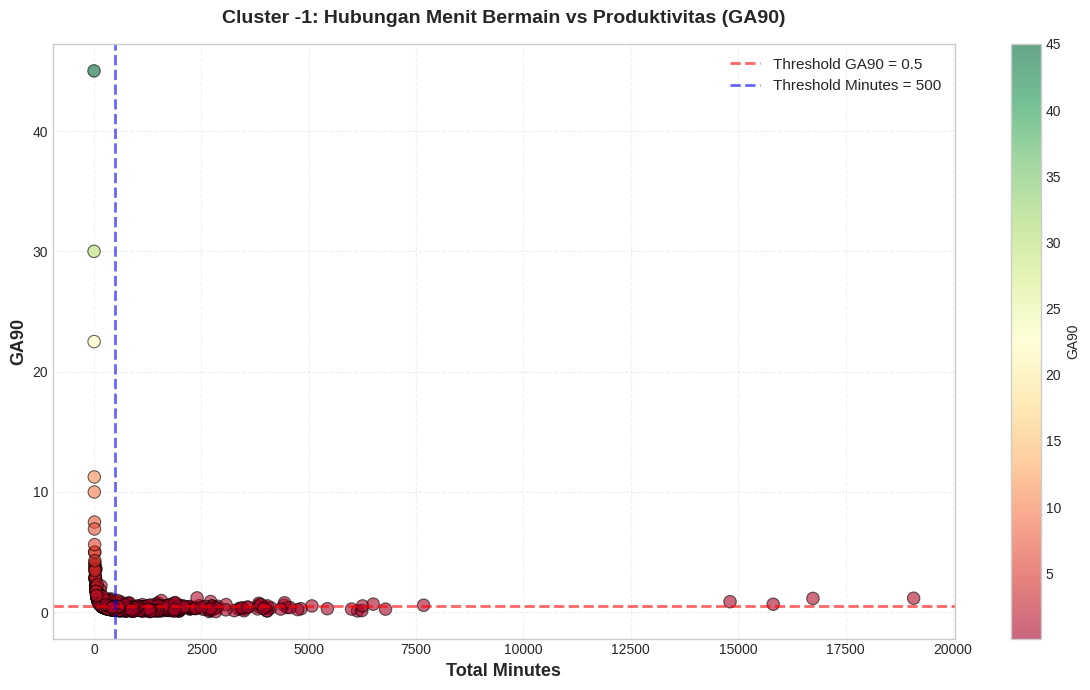


ANALISIS PEMAIN BERDASARKAN SAMPLE SIZE

1. Pemain dengan menit < 200 (sample sangat kecil):
   Jumlah: 106 pemain (23.3%)
   GA90 rata-rata: 2.80
   GA90 median: 1.30

2. Pemain dengan menit >= 500 (sample memadai):
   Jumlah: 261 pemain (57.5%)
   GA90 rata-rata: 0.37
   GA90 median: 0.33

CONTOH PEMAIN DENGAN NILAI EKSTREM

Top 5 Pemain dengan GA90 Tertinggi (Menit < 500):
----------------------------------------------------------------------
  • Jesper Uneken                  | Eindhovense Voetbalvereniging Philips Sport Vereniging | Menit:    2 | GA90:  45.00
  • André Ferreira                 | CS Marítimo               | Menit:    3 | GA90:  30.00
  • Tommaso De Nipoti              | Atalanta Bergamasca Calcio S.p.a. | Menit:    4 | GA90:  22.50
  • Jack Lahne                     | Amiens SC                 | Menit:    8 | GA90:  11.25
  • Clayton                        | Futbolniy Klub Dynamo Kyiv | Menit:    9 | GA90:  10.00

Top 5 Pemain dengan GA90 Tertinggi (Menit >= 500):

In [ ]:
print("="*70)
print("ANALISIS CLUSTER -1 (OUTLIER/NOISE)")
print("="*70)

# Fokus pada cluster -1
outlier_data = df_cluster[df_cluster["cluster"] == -1].copy()

print(f"\nJumlah pemain di Cluster -1: {len(outlier_data)}")
print(f"Persentase dari total: {len(outlier_data)/len(df_cluster)*100:.1f}%")

# ========================================
# ANALISIS DISTRIBUSI BERDASARKAN MENIT
# ========================================
print("\n" + "-"*70)
print("DISTRIBUSI BERDASARKAN TOTAL MENIT BERMAIN")
print("-"*70)

# Kategorikan berdasarkan menit
outlier_data['kategori_menit'] = pd.cut(
    outlier_data['total_minutes'],
    bins=[0, 200, 500, 1000, 20000],
    labels=['Sangat Minimal (<200)', 'Terbatas (200-500)',
            'Moderat (500-1000)', 'Memadai (>1000)']
)

print("\nDistribusi berdasarkan kategori menit:")
kategori_dist = outlier_data['kategori_menit'].value_counts().sort_index()
for kat, count in kategori_dist.items():
    pct = count / len(outlier_data) * 100
    print(f"  {kat}: {count} pemain ({pct:.1f}%)")

# Statistik GA90 per kategori menit
print("\n" + "-"*70)
print("Statistik GA90 per Kategori Menit:")
print("-"*70)
stats_by_minutes = outlier_data.groupby('kategori_menit')['GA90'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
])
print(stats_by_minutes.round(2))

# ========================================
# VISUALISASI SCATTER PLOT
# ========================================
print("\n" + "-"*70)
print("MEMBUAT VISUALISASI")
print("-"*70)

plt.figure(figsize=(12, 7))

# Scatter plot: total_minutes vs GA90
scatter = plt.scatter(outlier_data['total_minutes'],
                     outlier_data['GA90'],
                     c=outlier_data['GA90'],
                     cmap='RdYlGn',
                     s=80, alpha=0.6, edgecolors='black', linewidth=0.8)

plt.xlabel('Total Minutes', fontsize=13, fontweight='bold')
plt.ylabel('GA90', fontsize=13, fontweight='bold')
plt.title('Cluster -1: Hubungan Menit Bermain vs Produktivitas (GA90)',
          fontsize=14, fontweight='bold', pad=15)

# Threshold lines
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.6,
           linewidth=2, label='Threshold GA90 = 0.5')
plt.axvline(x=500, color='blue', linestyle='--', alpha=0.6,
           linewidth=2, label='Threshold Minutes = 500')

plt.legend(loc='upper right', fontsize=11)
plt.grid(alpha=0.3, linestyle='--')
plt.colorbar(scatter, label='GA90')

plt.tight_layout()
plt.show()

# ========================================
# ANALISIS PEMAIN DENGAN SAMPLE KECIL
# ========================================
print("\n" + "="*70)
print("ANALISIS PEMAIN BERDASARKAN SAMPLE SIZE")
print("="*70)

# Pemain dengan sample sangat kecil
very_small = outlier_data[outlier_data['total_minutes'] < 200]
print(f"\n1. Pemain dengan menit < 200 (sample sangat kecil):")
print(f"   Jumlah: {len(very_small)} pemain ({len(very_small)/len(outlier_data)*100:.1f}%)")
print(f"   GA90 rata-rata: {very_small['GA90'].mean():.2f}")
print(f"   GA90 median: {very_small['GA90'].median():.2f}")

# Pemain dengan sample memadai
adequate = outlier_data[outlier_data['total_minutes'] >= 500]
print(f"\n2. Pemain dengan menit >= 500 (sample memadai):")
print(f"   Jumlah: {len(adequate)} pemain ({len(adequate)/len(outlier_data)*100:.1f}%)")
print(f"   GA90 rata-rata: {adequate['GA90'].mean():.2f}")
print(f"   GA90 median: {adequate['GA90'].median():.2f}")

# ========================================
# CONTOH PEMAIN EKSTREM
# ========================================
print("\n" + "="*70)
print("CONTOH PEMAIN DENGAN NILAI EKSTREM")
print("="*70)

print("\nTop 5 Pemain dengan GA90 Tertinggi (Menit < 500):")
print("-"*70)
extreme_small = outlier_data[outlier_data['total_minutes'] < 500].nlargest(5, 'GA90')
for idx, row in extreme_small.iterrows():
    print(f"  • {row['player_name']:30} | {row['club_name']:25} | "
          f"Menit: {row['total_minutes']:4.0f} | GA90: {row['GA90']:6.2f}")

print("\nTop 5 Pemain dengan GA90 Tertinggi (Menit >= 500):")
print("-"*70)
extreme_adequate = outlier_data[outlier_data['total_minutes'] >= 500].nlargest(5, 'GA90')
for idx, row in extreme_adequate.iterrows():
    print(f"  • {row['player_name']:30} | {row['club_name']:25} | "
          f"Menit: {row['total_minutes']:4.0f} | GA90: {row['GA90']:6.2f}")